In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers pandas scikit-learn scipy tqdm matplotlib accelerate

import os, json, random
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
MODEL_NAME = "roberta-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MAX_LEN = 512
BATCH = 2
ACCUM = 8
EPOCHS = 11
LR = 1e-5
WEIGHT_DECAY = 0.01
PATIENCE = 3
MULTIPLIER = 6

TRAITS = ["openness","conscientiousness","extraversion","agreeableness","neuroticism"]

DATA_PATH = "/content/drive/MyDrive/pandora/pandora_user_level_paper_108.parquet"
SAVE_DIR = "/content/drive/MyDrive/roberta_personality_model"

os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
df = pd.read_parquet(DATA_PATH)
df = df.dropna(subset=TRAITS).reset_index(drop=True)
df["uid"] = df.index

print("Users:", len(df))

trait_means = df[TRAITS].mean()
trait_stds = df[TRAITS].std() + 1e-6

df[TRAITS] = (df[TRAITS] - trait_means) / trait_stds

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

Users: 1484


In [ ]:
class Pandora(Dataset):
    def __init__(self, df):
        self.text = df.text.tolist()
        self.y = df[TRAITS].values.astype(np.float32)
        self.u = df.uid.tolist()

    def __len__(self):
        return len(self.text) * MULTIPLIER

    def __getitem__(self, i):
        i %= len(self.text)

        t = self.text[i]
        w = t.split()
        if len(w) > 800:
            s = random.randint(0, len(w) - 800)
            t = " ".join(w[s:s+800])

        enc = tokenizer(
            t,
            truncation=True,
            max_length=MAX_LEN,
            padding="max_length",
            return_tensors="pt"
        )

        y = torch.tensor(self.y[i]) * 0.9

        return (
            enc["input_ids"].squeeze(),
            enc["attention_mask"].squeeze(),
            y,
            torch.tensor(self.u[i])
        )

train_loader = DataLoader(Pandora(train_df), batch_size=BATCH, shuffle=True)
val_loader = DataLoader(Pandora(val_df), batch_size=BATCH)

In [ ]:
class RobertaReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = AutoModel.from_pretrained(MODEL_NAME)
        hidden_size = self.enc.config.hidden_size

        self.att = nn.Linear(hidden_size, 1)

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.4)
        )

        self.heads = nn.ModuleList(
            [nn.Linear(128, 1) for _ in range(5)]
        )

    def forward(self, i, m):
        x = self.enc(input_ids=i, attention_mask=m).last_hidden_state
        w = torch.softmax(self.att(x), 1)
        x = (x * w).sum(1)
        x = self.fc(x)
        return torch.cat([h(x) for h in self.heads], 1)

model = RobertaReg().to(DEVICE)

# Freeze initially
for p in model.enc.parameters():
    p.requires_grad = False

print("Model initialized successfully")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model initialized successfully


In [ ]:
loss_fn = nn.SmoothL1Loss()

opt = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

steps = (len(train_loader) * EPOCHS) // ACCUM

sched = get_cosine_schedule_with_warmup(opt, 0, steps)

scaler = torch.cuda.amp.GradScaler()

/tmp/ipython-input-256/3064825243.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
best = 1e9
bad = 0
train_hist = []
val_hist = []

for ep in range(EPOCHS):

    if ep == 3:
        for layer in model.enc.encoder.layer[-2:]:
            for p in layer.parameters():
                p.requires_grad = True

    if ep == 5:
        for p in model.enc.parameters():
            p.requires_grad = True

    model.train()
    opt.zero_grad()
    ls = []

    for s, (i, m, y, _) in enumerate(tqdm(train_loader)):
        i, m, y = i.to(DEVICE), m.to(DEVICE), y.to(DEVICE)

        with torch.cuda.amp.autocast():
            loss = loss_fn(model(i, m), y) / ACCUM

        scaler.scale(loss).backward()

        if (s + 1) % ACCUM == 0:
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
            scaler.step(opt)
            scaler.update()
            sched.step()
            opt.zero_grad()

        ls.append(loss.item() * ACCUM)

    tr = np.mean(ls)

    model.eval()
    vs = []

    with torch.no_grad():
        for i, m, y, _ in val_loader:
            vs.append(
                loss_fn(
                    model(i.to(DEVICE), m.to(DEVICE)),
                    y.to(DEVICE)
                ).item()
            )

    vl = np.mean(vs)

    train_hist.append(tr)
    val_hist.append(vl)

    print(f"Epoch {ep+1} | Train {tr:.3f} | Val {vl:.3f}")

    if vl < best:
        best = vl
        bad = 0
        torch.save(model.state_dict(), f"{SAVE_DIR}/model.pt")
    else:
        bad += 1
        if bad >= PATIENCE:
            print("Early stop")
            break

  0%|          | 0/3561 [00:00<?, ?it/s]/tmp/ipython-input-256/1308800180.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 3561/3561 [01:36<00:00, 36.73it/s]


Epoch 1 | Train 0.388 | Val 0.382


100%|██████████| 3561/3561 [01:30<00:00, 39.32it/s]


Epoch 2 | Train 0.385 | Val 0.382


100%|██████████| 3561/3561 [01:30<00:00, 39.26it/s]


...

Epoch 7 | Train 0.349 | Val 0.366


100%|██████████| 3561/3561 [04:29<00:00, 13.19it/s]


Epoch 8 | Train 0.338 | Val 0.378


100%|██████████| 3561/3561 [04:31<00:00, 13.12it/s]


Epoch 9 | Train 0.331 | Val 0.375
Early stop


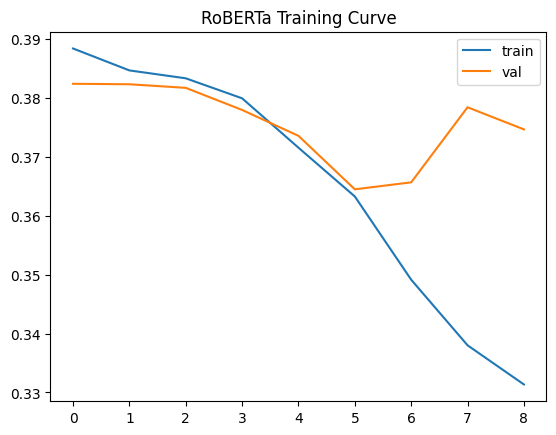

In [ ]:
plt.plot(train_hist)
plt.plot(val_hist)
plt.legend(["train", "val"])
plt.title("RoBERTa Training Curve")
plt.show()

In [ ]:
model.load_state_dict(torch.load(f"{SAVE_DIR}/model.pt"))
model.eval()

P = defaultdict(list)
T = {}

with torch.no_grad():
    for i, m, y, u in val_loader:
        o = model(i.to(DEVICE), m.to(DEVICE)).cpu()
        for k, uid in enumerate(u):
            P[uid.item()].append(o[k])
            T[uid.item()] = y[k]

X = []
Y = []

for u in P:
    X.append(torch.stack(P[u]).mean(0))
    Y.append(T[u])

X = torch.stack(X).numpy() * trait_stds.values + trait_means.values
Y = torch.stack(Y).numpy() * trait_stds.values + trait_means.values

print("\n=== FINAL ROBERTA METRICS ===")

for i, t in enumerate(TRAITS):
    mae = mean_absolute_error(Y[:, i], X[:, i])
    mse = mean_squared_error(Y[:, i], X[:, i])
    rmse = np.sqrt(mse)
    r = pearsonr(Y[:, i], X[:, i])[0]
    print(t, "MAE", mae, "MSE", mse, "RMSE", rmse, "R", r)

print("\nMacro MAE:", mean_absolute_error(Y, X))
print("Macro RMSE:", np.sqrt(mean_squared_error(Y, X)))
print("R2:", r2_score(Y, X))


=== FINAL ROBERTA METRICS ===
openness MAE 20.35833616929126 MSE 589.6580121024782 RMSE 24.282874873096848 R 0.23637559557217153
conscientiousness MAE 22.854288521079212 MSE 717.8034543164824 RMSE 26.791854253046438 R 0.2348852652703666
extraversion MAE 22.765166330348897 MSE 749.262862338792 RMSE 27.372666335941627 R 0.24339748172481346
agreeableness MAE 23.44006281971236 MSE 716.9801474981799 RMSE 26.77648497279245 R 0.2443543652257928
neuroticism MAE 24.374628836049737 MSE 766.685378546258 RMSE 27.689084104503312 R 0.3030608886060854

Macro MAE: 22.758496535296302
Macro RMSE: 26.60973451503111
R2: 0.049075670596885536


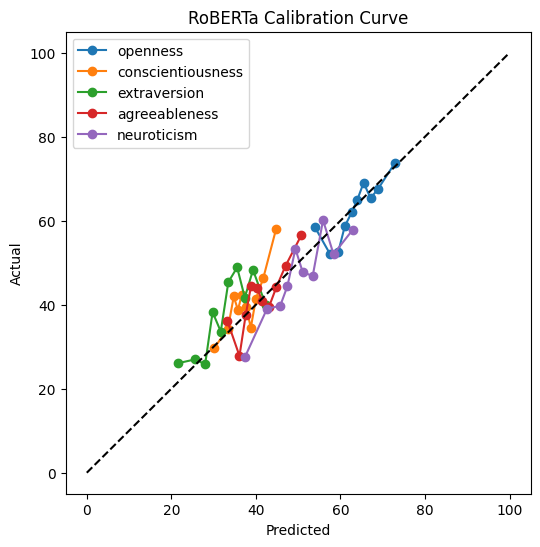

In [ ]:
# ================= CALIBRATION =================

def calib(y_true, y_pred):
    idx = np.argsort(y_pred)
    y_true = y_true[idx]
    y_pred = y_pred[idx]

    bins = 10
    size = len(y_true) // bins

    xs = []
    ys = []

    for i in range(bins):
        start = i * size
        end = (i + 1) * size if i < bins - 1 else len(y_true)

        xs.append(y_pred[start:end].mean())
        ys.append(y_true[start:end].mean())

    return xs, ys


plt.figure(figsize=(6,6))

for i, trait in enumerate(TRAITS):
    xs, ys = calib(Y[:, i], X[:, i])
    plt.plot(xs, ys, marker='o', label=trait)

plt.plot([0,100],[0,100],'--', color='black')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RoBERTa Calibration Curve")
plt.legend()
plt.show()